# Country-level Difference-in-Differences Analysis of Google AI Overviews

This notebook investigates whether the March 2025 rollout of Google AI Overviews affected Wikipedia pageviews across European countries using a country-level Difference-in-Differences design.

## Data source

This analysis uses the public Wikimedia Differential Privacy CSV dumps from:

https://analytics.wikimedia.org/published/datasets/country_project_page/

I use the public CSV dumps instead of the country endpoint from the Analytics API because the API returns bucketed values such as `1000000-9999999`, which are not suitable for Difference-in-Differences estimation.

## Download and aggregate daily country pageviews

The Wikimedia dataset contains one compressed TSV file per day.

This step downloads all daily files, aggregates pageviews at the country level, and stores the result as a local CSV file.

Runtime: approximately 40–45 minutes.

This step only needs to be executed once. After the aggregated CSV has been created, the notebook can be restarted from the next section.

In [22]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm
import os
import gc

base = "https://analytics.wikimedia.org/published/datasets/country_project_page/"

html = requests.get(base).text
soup = BeautifulSoup(html, "html.parser")

files = sorted(
    a.get("href")
    for a in soup.find_all("a")
    if a.get("href", "").endswith(".tsv")
)

analysis_files = [
    f for f in files
    if f <= "2026-06-30.tsv"
]

target_countries = ["AT", "BE", "CH", "DE", "ES", "FR", "IE", "IT", "PL", "PT"]

def aggregate_wikipedia_pageviews_for_day(file_name):
    url = base + file_name
    
    columns = [
        "country",
        "country_code",
        "project",
        "page_id",
        "page_title",
        "item_id",
        "gbc"
    ]
    
    df = pd.read_csv(
        url,
        sep="\t",
        header=None,
        names=columns,
        usecols=["country_code", "project", "gbc"]
    )
    
    daily = (
        df[
            (df["country_code"].isin(target_countries)) &
            (df["project"].str.endswith(".wikipedia"))
        ]
        .groupby("country_code", as_index=False)["gbc"]
        .sum()
        .rename(columns={"gbc": "wikipedia_pageviews"})
    )
    
    daily["date"] = pd.to_datetime(file_name.replace(".tsv", ""))
    
    del df
    gc.collect()
    
    return daily

output_file = "country_daily_pageviews_10_countries.csv"

if os.path.exists(output_file):
    os.remove(output_file)

failed_files = []

for file in tqdm(analysis_files):
    try:
        daily = aggregate_wikipedia_pageviews_for_day(file)
        
        daily.to_csv(
            output_file,
            mode="a",
            header=not os.path.exists(output_file),
            index=False
        )
        
    except Exception as e:
        failed_files.append((file, str(e)))

len(failed_files), failed_files[:5]

  0%|          | 0/1241 [00:00<?, ?it/s]

(2,
 [('2024-12-05.tsv',
   'Error tokenizing data. C error: EOF inside string starting at row 334953'),
  ('2024-12-09.tsv',
   'Error tokenizing data. C error: EOF inside string starting at row 359343')])

## Load aggregated dataset

The following sections use the aggregated CSV generated in the previous step.

If the CSV already exists, the download step can be skipped.

In [23]:
daily_panel = pd.read_csv("country_daily_pageviews_10_countries.csv")

daily_panel.head()

,country_code,wikipedia_pageviews,date
0,AT,324662,2023-02-06
1,BE,311937,2023-02-06
2,CH,184825,2023-02-06
3,DE,8399945,2023-02-06
4,ES,2124147,2023-02-06


In [24]:
daily_panel["country_code"].value_counts().sort_index()

country_code
AT    1239
BE    1239
CH    1239
DE    1239
ES    1239
FR    1239
IE    1239
IT    1239
PL    1239
PT    1239
Name: count, dtype: int64

## Recover corrupted daily dumps

Two daily dump files contained malformed rows and could not be parsed using the standard pipeline.

These files are reprocessed separately and then merged into the aggregated dataset.

In [25]:
bad_files = ["2024-12-05.tsv", "2024-12-09.tsv"]

fixed_days = []

for file_name in bad_files:
    url = base + file_name
    
    columns = [
        "country",
        "country_code",
        "project",
        "page_id",
        "page_title",
        "item_id",
        "gbc"
    ]
    
    df_bad = pd.read_csv(
        url,
        sep="\t",
        header=None,
        names=columns,
        usecols=["country_code", "project", "gbc"],
        engine="python",
        on_bad_lines="skip"
    )
    
    daily_bad = (
        df_bad[
            (df_bad["country_code"].isin(target_countries)) &
            (df_bad["project"].str.endswith(".wikipedia"))
        ]
        .groupby("country_code", as_index=False)["gbc"]
        .sum()
        .rename(columns={"gbc": "wikipedia_pageviews"})
    )
    
    daily_bad["date"] = pd.to_datetime(file_name.replace(".tsv", ""))
    
    fixed_days.append(daily_bad)

fixed_days = pd.concat(fixed_days, ignore_index=True)

fixed_days

,country_code,wikipedia_pageviews,date
0,AT,259482,2024-12-05
1,BE,225166,2024-12-05
2,CH,164316,2024-12-05
3,DE,6762994,2024-12-05
4,ES,1799932,2024-12-05
5,FR,6378676,2024-12-05
6,IE,236455,2024-12-05
7,IT,4148548,2024-12-05
8,PL,1376126,2024-12-05
9,PT,134456,2024-12-05


## Verify repaired dataset

In [26]:
daily_panel_fixed = pd.concat(
    [daily_panel, fixed_days],
    ignore_index=True
)

daily_panel_fixed = daily_panel_fixed.sort_values(["country_code", "date"])

daily_panel_fixed["country_code"].value_counts().sort_index()

country_code
AT    1241
BE    1241
CH    1241
DE    1241
ES    1241
FR    1241
IE    1241
IT    1241
PL    1241
PT    1241
Name: count, dtype: int64

In [27]:
daily_panel_fixed.to_csv(
    "country_daily_pageviews_10_countries_fixed.csv",
    index=False
)

# Exploratory Data Analysis

In this section we explore the country-level panel before applying Difference-in-Differences.

The goals are:

- verify data completeness;
- inspect overall trends and seasonality;
- identify suitable treatment and control groups;
- evaluate the plausibility of the parallel trends assumption.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Load analysis dataset

In [30]:
daily_panel = pd.read_csv("country_daily_pageviews_10_countries_fixed.csv")

daily_panel["date"] = pd.to_datetime(
    daily_panel["date"],
    format="mixed"
)

daily_panel.head()


,country_code,wikipedia_pageviews,date
0,AT,259482,2024-12-05
1,AT,380971,2024-12-09
2,AT,324662,2023-02-06
3,AT,374169,2023-02-07
4,AT,443761,2023-02-08


In [31]:
daily_panel["date"].min(), daily_panel["date"].max()

(Timestamp('2023-02-06 00:00:00'), Timestamp('2026-06-30 00:00:00'))

## Convert daily observations to monthly panel

Daily pageviews are aggregated to monthly totals because the analysis is performed at the monthly country level.

In [32]:
monthly = (
    daily_panel
    .assign(month=daily_panel["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["country_code", "month"], as_index=False)
    .agg(pageviews=("wikipedia_pageviews", "sum"))
)

monthly.head()

,country_code,month,pageviews
0,AT,2023-02-01,9216110
1,AT,2023-03-01,12132565
2,AT,2023-04-01,10328430
3,AT,2023-05-01,11114971
4,AT,2023-06-01,9146060


In [33]:
monthly_wide = (
    monthly
    .pivot(index="month",
           columns="country_code",
           values="pageviews")
    .sort_index()
)

monthly_wide.head()

country_code,AT,BE,CH,DE,ES,FR,IE,IT,PL,PT
month,,,,,,,,,,
2023-02-01,9216110,9121934,5401539,276058548,69899109,168758764,7643068,155448230,53627227,5182434
2023-03-01,12132565,12630841,8741606,340787208,92053602,240559511,11791986,183170467,72050815,7514543
2023-04-01,10328430,9206480,5862628,276042988,74295347,187327506,8791362,170723507,61891580,4766171
2023-05-01,11114971,12331439,7066145,262368222,96719362,215870505,10151911,203545479,71199580,7566987
2023-06-01,9146060,8909579,5712315,217912204,65996582,153181341,7718131,150588784,50560863,4768049


In [34]:
monthly_wide.shape

(41, 10)

In [35]:
monthly_wide.isna().sum()

country_code
AT    0
BE    0
CH    0
DE    0
ES    0
FR    0
IE    0
IT    0
PL    0
PT    0
dtype: int64

## Overall trends

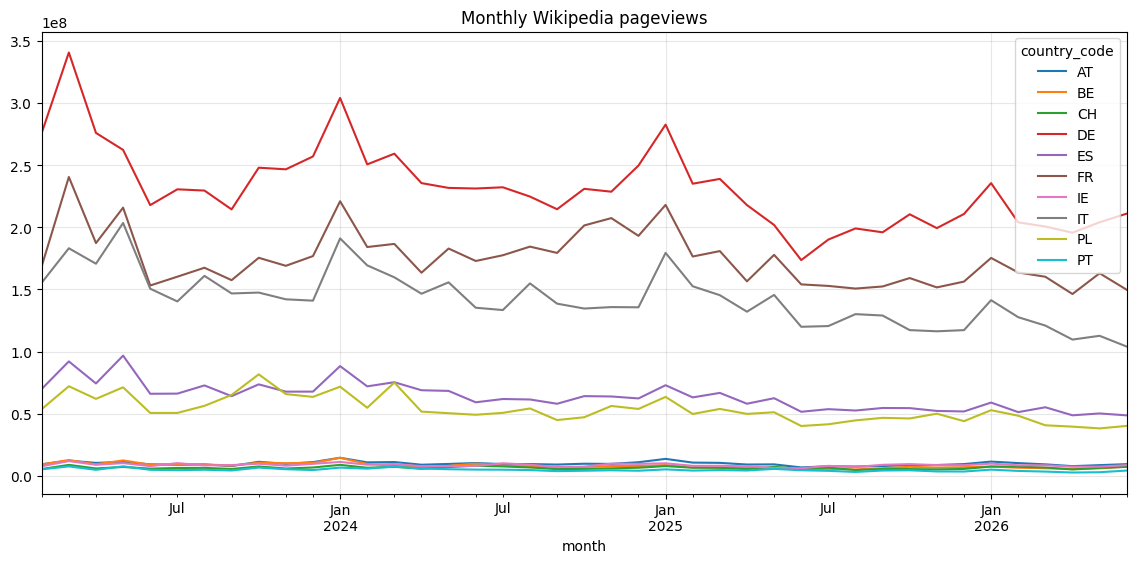

In [36]:
monthly_wide.plot(figsize=(14,6))
plt.title("Monthly Wikipedia pageviews")
plt.grid(alpha=0.3)
plt.show()

In [37]:
pre_end = pd.Timestamp("2025-02-28")

pre = monthly_wide.loc[monthly_wide.index <= pre_end].copy()

pre_indexed = pre.divide(pre.iloc[0]).multiply(100)

pre_indexed.head()

country_code,AT,BE,CH,DE,ES,FR,IE,IT,PL,PT
month,,,,,,,,,,
2023-02-01,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2023-03-01,131.645184,138.466700,161.835469,123.447439,131.694958,142.546381,154.283411,117.833742,134.354915,145.000264
2023-04-01,112.069300,100.926843,108.536252,99.994364,106.289405,111.003128,115.023993,109.826601,115.410741,91.967809
2023-05-01,120.603715,135.184480,130.817254,95.040789,138.369950,127.916619,132.825078,130.941008,132.767596,146.012221
2023-06-01,99.239918,97.672040,105.753471,78.936952,94.416915,90.769414,100.982106,96.873914,94.282076,92.004047


## France as a candidate control group

Before estimating a Difference-in-Differences model, it is important to assess whether candidate control countries exhibit trends similar to France during the pre-treatment period.

The figure below compares normalized monthly pageviews. Each series is indexed to 100 in its first observed month to facilitate visual comparison of trends rather than absolute traffic volumes.

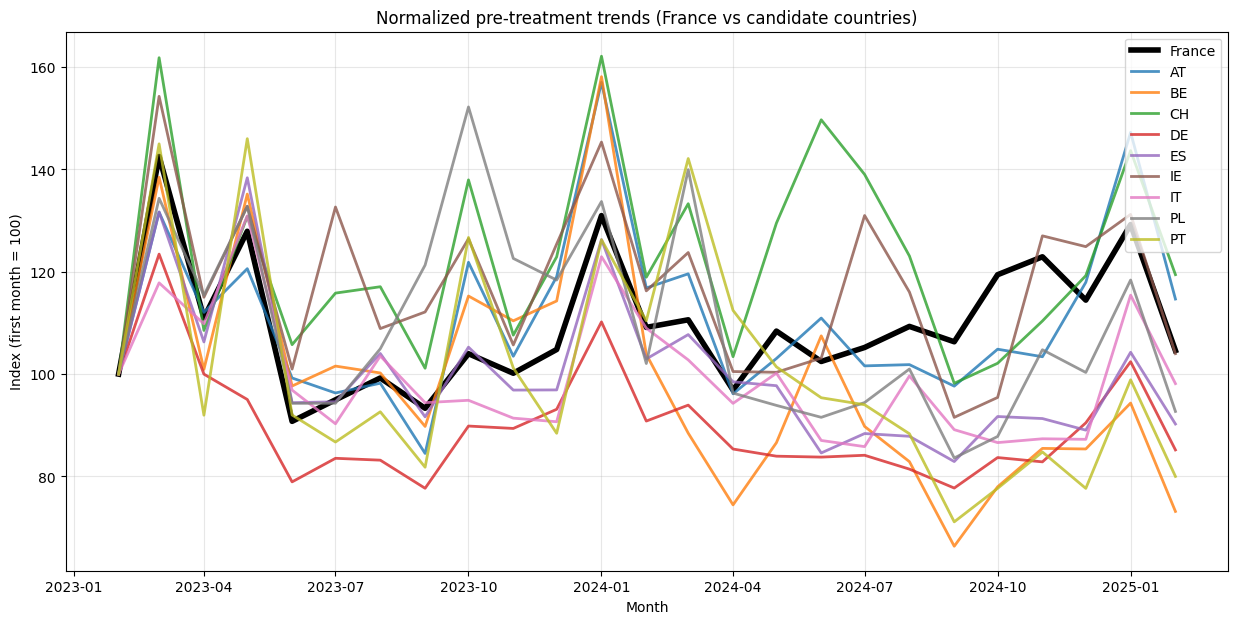

In [38]:
treated_codes = ["AT", "BE", "CH", "DE", "ES", "IE", "IT", "PL", "PT"]

plt.figure(figsize=(15, 7))

plt.plot(
    pre_indexed.index,
    pre_indexed["FR"],
    linewidth=4,
    color="black",
    label="France"
)

for code in treated_codes:
    plt.plot(
        pre_indexed.index,
        pre_indexed[code],
        linewidth=2,
        alpha=0.8,
        label=code
    )

plt.title("Normalized pre-treatment trends (France vs candidate countries)")
plt.ylabel("Index (first month = 100)")
plt.xlabel("Month")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Pairwise comparison with France

The aggregate comparison above may hide pair-specific differences.

To inspect potential deviations in more detail, each candidate country is compared individually against France.

In [39]:
treated_codes = ["AT", "BE", "CH", "DE", "ES", "IE", "IT", "PL", "PT"]

country_names = {
    "AT": "Austria",
    "BE": "Belgium",
    "CH": "Switzerland",
    "DE": "Germany",
    "ES": "Spain",
    "FR": "France",
    "IE": "Ireland",
    "IT": "Italy",
    "PL": "Poland",
    "PT": "Portugal"
}

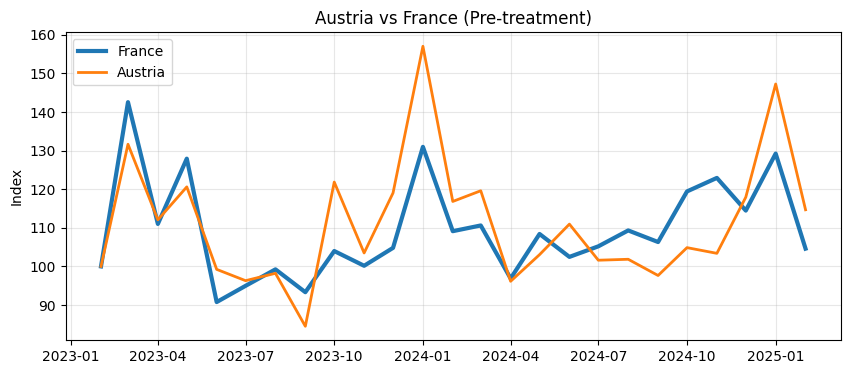

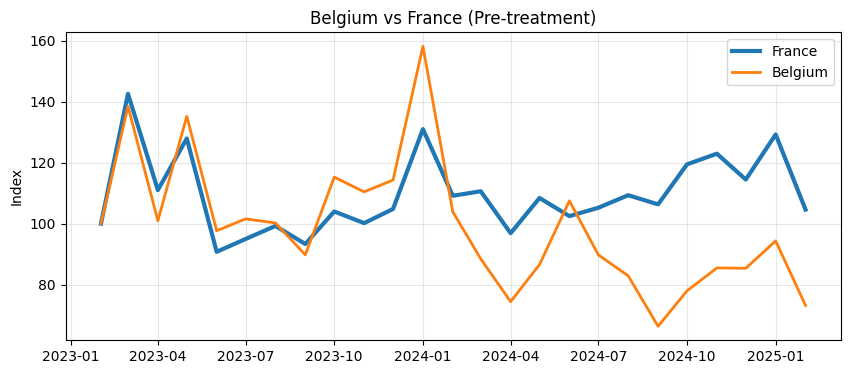

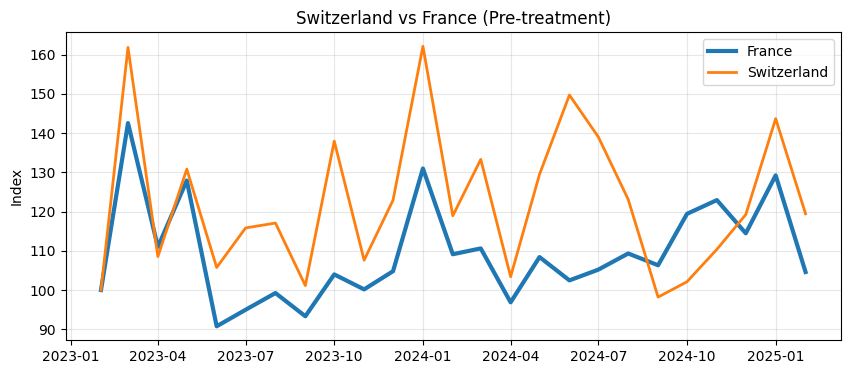

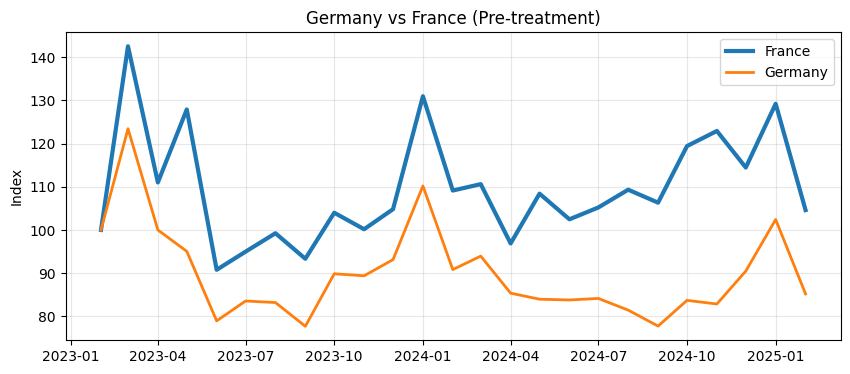

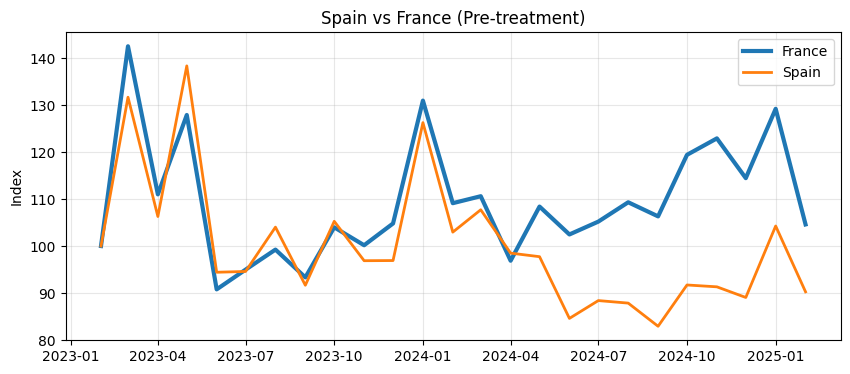

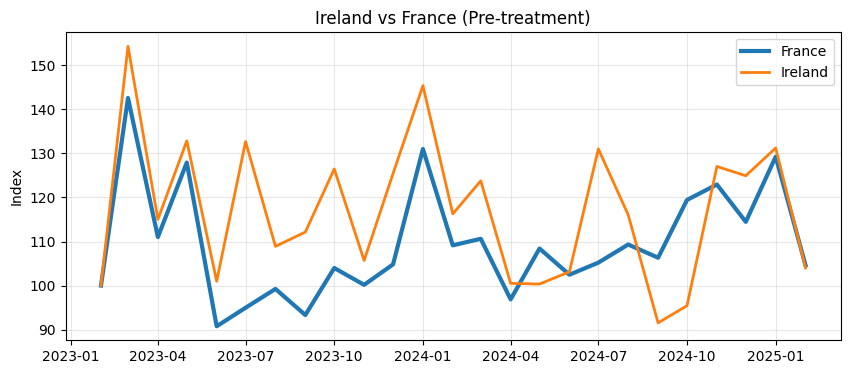

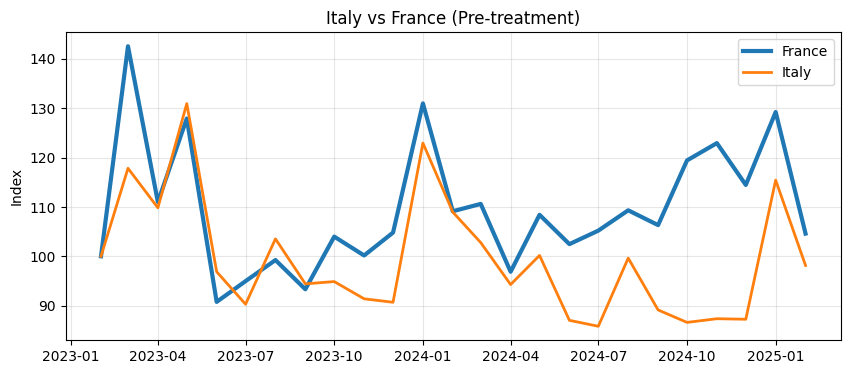

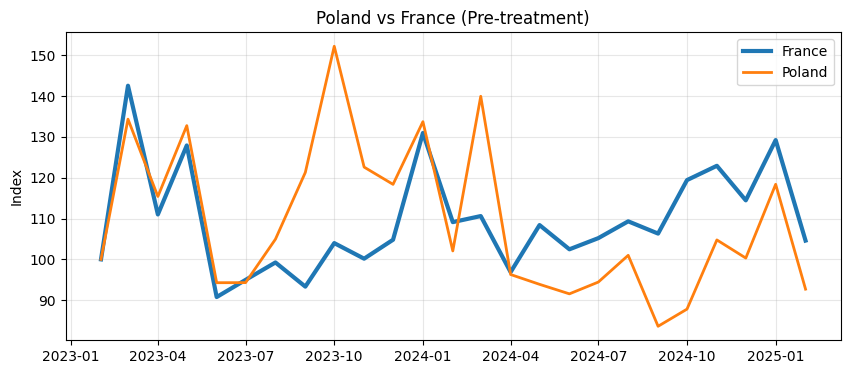

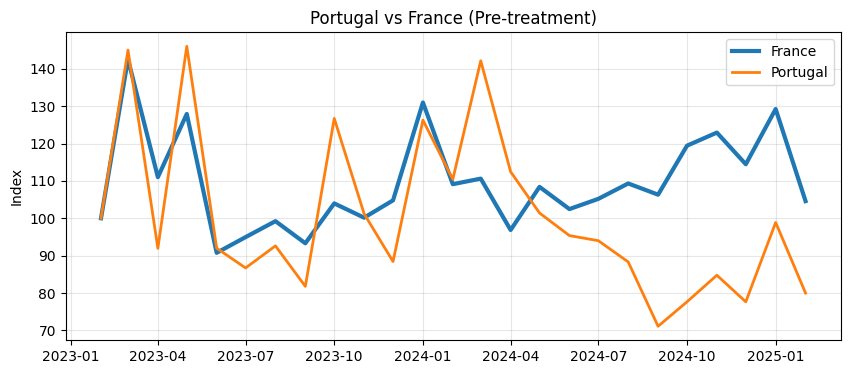

In [40]:
for code in treated_codes:

    plt.figure(figsize=(10,4))

    plt.plot(
        pre_indexed.index,
        pre_indexed["FR"],
        linewidth=3,
        label="France"
    )

    plt.plot(
        pre_indexed.index,
        pre_indexed[code],
        linewidth=2,
        label=country_names[code]
    )

    plt.title(f"{country_names[code]} vs France (Pre-treatment)")
    plt.ylabel("Index")
    plt.grid(alpha=.3)
    plt.legend()

    plt.show()

## Assessing France as a control group

Log-ratios provide a more sensitive diagnostic than normalized trends.

If France behaves similarly to the candidate control countries, these log-ratios should fluctuate independently around a stable level.

Instead, common movements across nearly all countries would indicate that the variation originates from France rather than from the treated countries.

In [41]:
log_ratio_fr = np.log(pre.drop(columns=["FR"])).subtract(
    np.log(pre["FR"]),
    axis=0
)

log_ratio_fr.head()

country_code,AT,BE,CH,DE,ES,IE,IT,PL,PT
month,,,,,,,,,
2023-02-01,-2.907517,-2.917788,-3.441786,0.492143,-0.881417,-3.094671,-0.082158,-1.146413,-3.483195
2023-03-01,-2.987074,-2.946826,-3.314874,0.348291,-0.960596,-3.015547,-0.272550,-1.205596,-3.466127
2023-04-01,-2.897958,-3.012951,-3.464260,0.387698,-0.924810,-3.059089,-0.092813,-1.107474,-3.671315
2023-05-01,-2.966386,-2.862527,-3.419364,0.195070,-0.802865,-3.057017,-0.058789,-1.109192,-3.350884
2023-06-01,-2.818299,-2.844495,-3.288998,0.352470,-0.842020,-2.988050,-0.017070,-1.108445,-3.469685


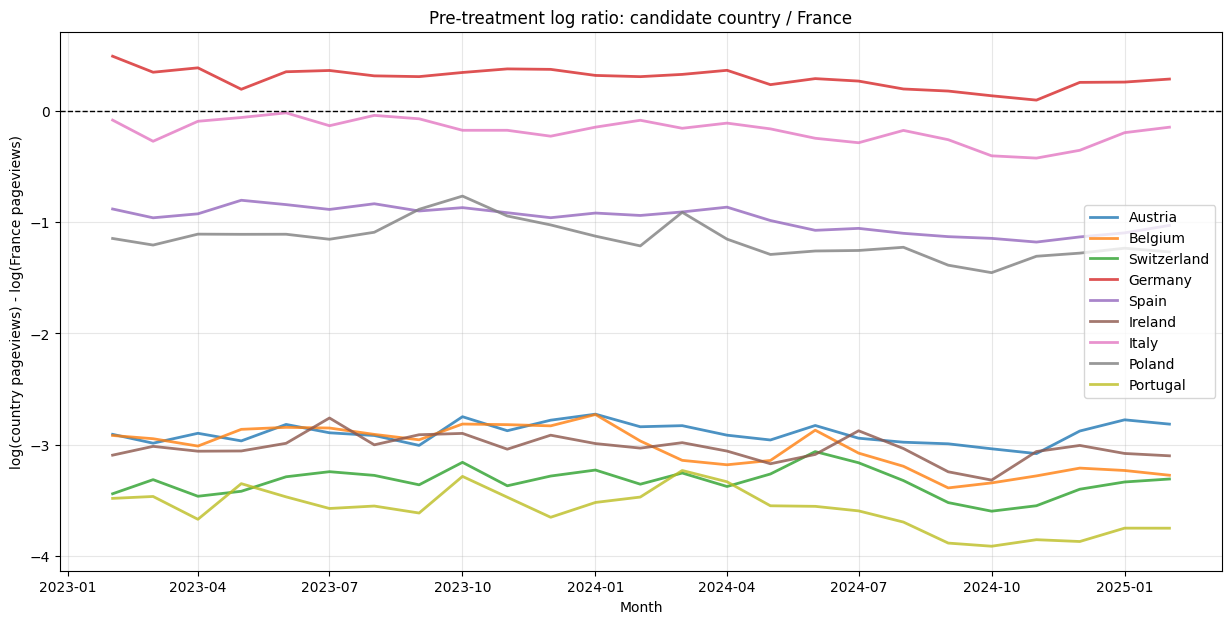

In [42]:
plt.figure(figsize=(15, 7))

for code in log_ratio_fr.columns:
    plt.plot(
        log_ratio_fr.index,
        log_ratio_fr[code],
        label=country_names[code],
        linewidth=2,
        alpha=0.8
    )

plt.axhline(0, color="black", linewidth=1, linestyle="--")

plt.title("Pre-treatment log ratio: candidate country / France")
plt.ylabel("log(country pageviews) - log(France pageviews)")
plt.xlabel("Month")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

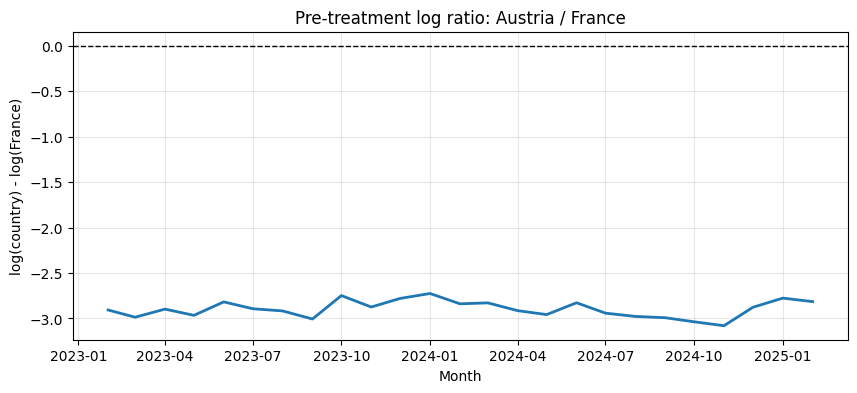

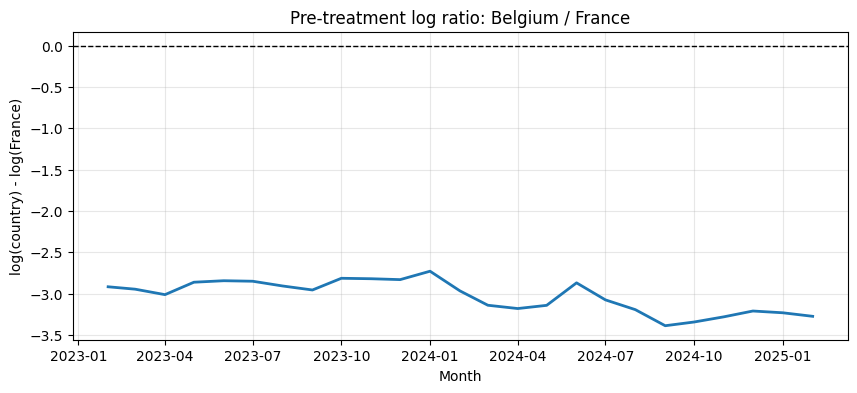

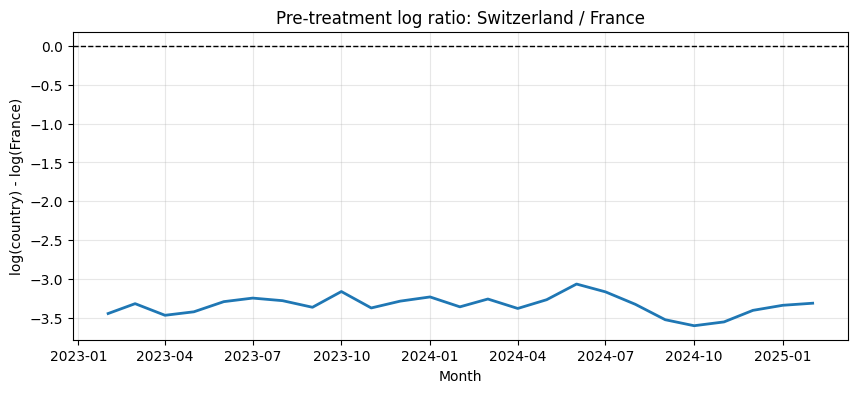

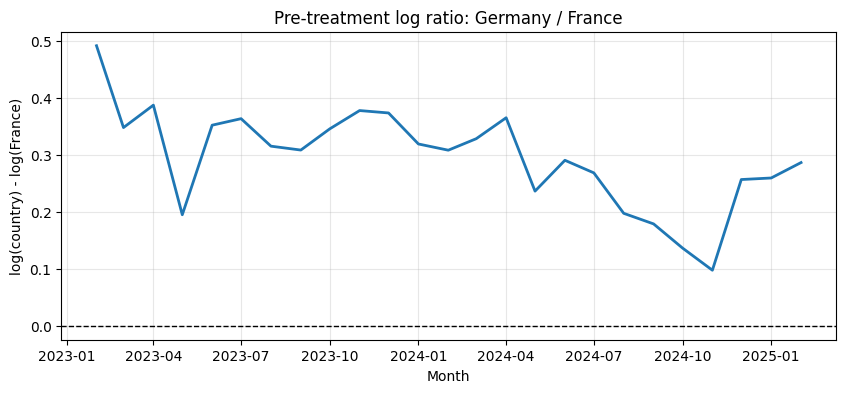

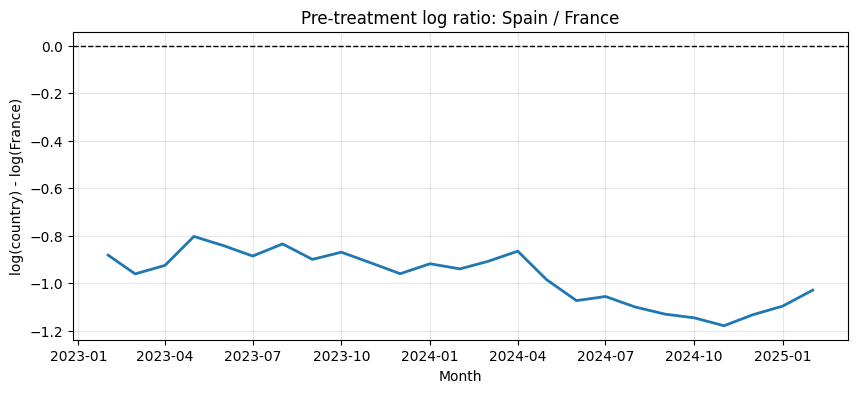

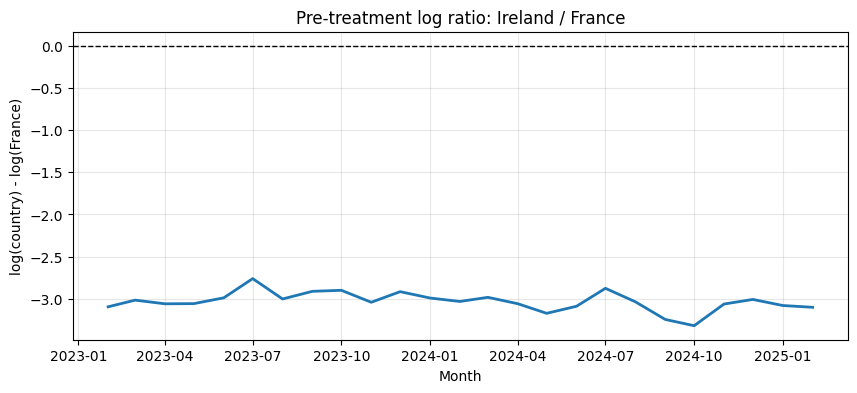

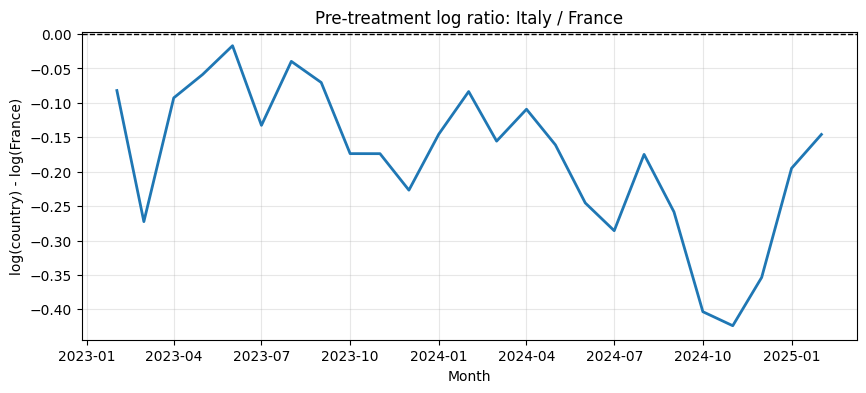

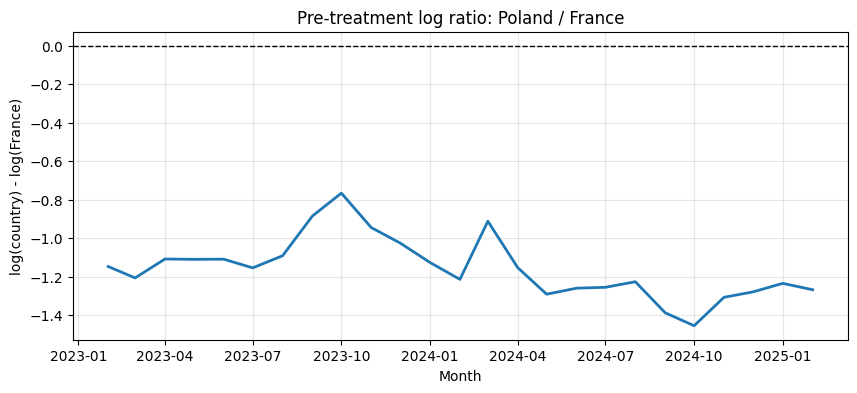

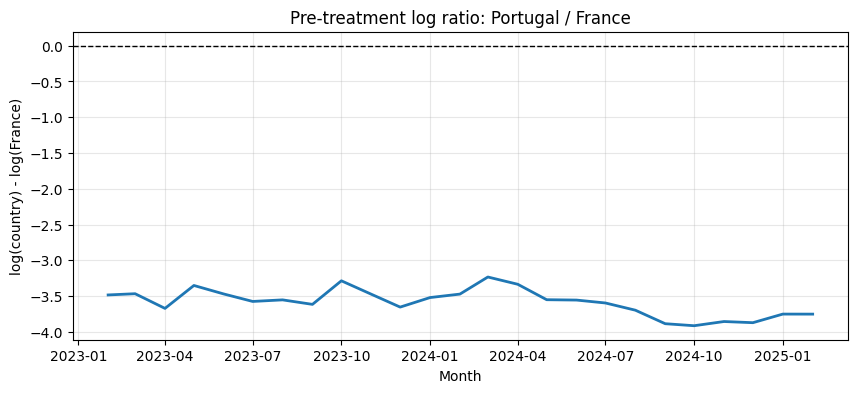

In [43]:
for code in treated_codes:
    plt.figure(figsize=(10, 4))
    
    plt.plot(
        log_ratio_fr.index,
        log_ratio_fr[code],
        linewidth=2
    )
    
    plt.axhline(0, color="black", linewidth=1, linestyle="--")
    
    plt.title(f"Pre-treatment log ratio: {country_names[code]} / France")
    plt.ylabel("log(country) - log(France)")
    plt.xlabel("Month")
    plt.grid(alpha=0.3)
    
    plt.show()

### Conclusion

The log-ratio analysis reveals a common movement across nearly all candidate countries relative to France during the pre-treatment period.

Because the deviation is shared across independent countries, it is most consistent with a France-specific shock rather than country-specific variation.

Therefore, France cannot serve as a reliable single control group for Difference-in-Differences estimation.

## Leave-one-out Wave 4 control

France is therefore replaced by a synthetic control constructed from the remaining Wave 4 countries.

For each country, the benchmark is defined as the average of all other Wave 4 countries (leave-one-out mean), reducing dependence on any single control country.

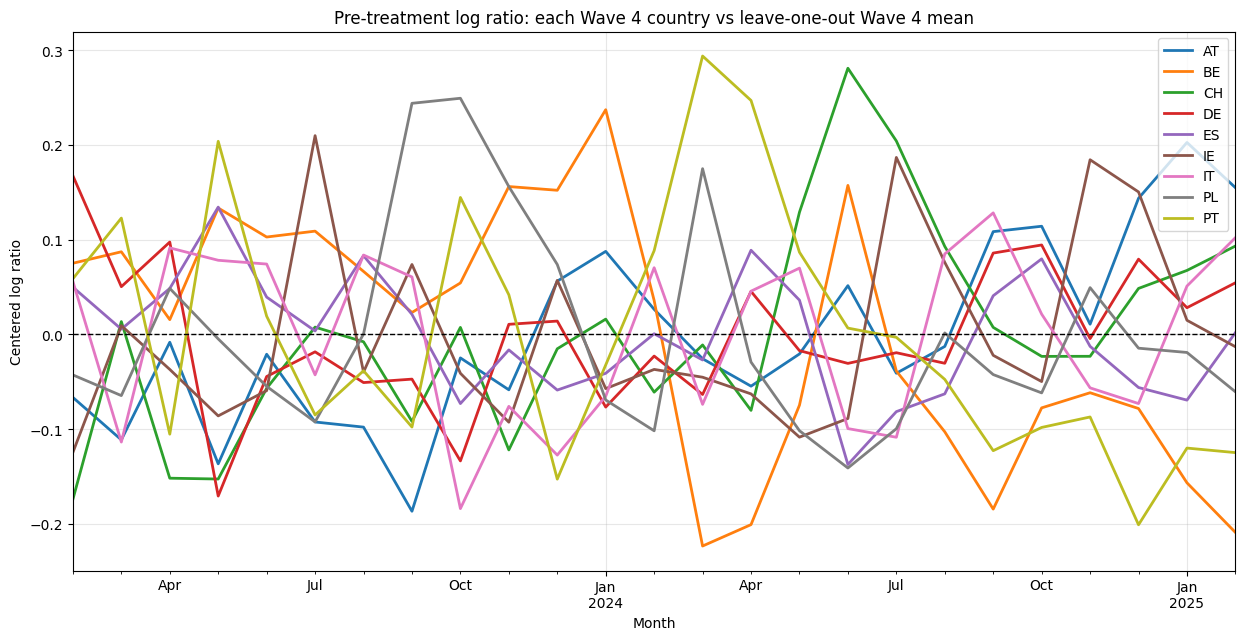

In [45]:
wave4 = ["AT", "BE", "CH", "DE", "ES", "IE", "IT", "PL", "PT"]

lp = np.log(monthly_wide)

pre_end = pd.Timestamp("2025-02-28")

plt.figure(figsize=(15, 7))

loo_ratios = {}

for c in wave4:
    others = [x for x in wave4 if x != c]
    
    ratio = lp[c] - lp[others].mean(axis=1)
    ratio_centered = ratio - ratio.loc[:pre_end].mean()
    
    loo_ratios[c] = ratio_centered
    
    ratio_centered.loc[:pre_end].plot(label=c, linewidth=2)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Pre-treatment log ratio: each Wave 4 country vs leave-one-out Wave 4 mean")
plt.ylabel("Centered log ratio")
plt.xlabel("Month")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

The leave-one-out comparison indicates that no single Wave 4 country exhibits substantially larger pre-treatment deviations than the others.

This suggests that the remaining Wave 4 countries form a stable reference group and can be used to construct an aggregate control.

The next step summarizes the pre-treatment variability of this aggregate benchmark.

## Comparing Wave 4 and Wave 5 groups

In [46]:
loo_pre = pd.DataFrame(loo_ratios).loc[:pre_end]

noise_summary = pd.DataFrame({
    "sd_monthly_log_ratio": loo_pre.std(),
    "min": loo_pre.min(),
    "max": loo_pre.max(),
    "range": loo_pre.max() - loo_pre.min()
}).sort_values("sd_monthly_log_ratio")

noise_summary

,sd_monthly_log_ratio,min,max,range
ES,0.063931,-0.137274,0.134442,0.271716
DE,0.075236,-0.170519,0.167544,0.338063
IT,0.089748,-0.183781,0.128362,0.312144
IE,0.096466,-0.124424,0.209886,0.334310
AT,0.096545,-0.186584,0.202707,0.389290
PL,0.106140,-0.140922,0.249355,0.390277
CH,0.107411,-0.173927,0.281038,0.454965
PT,0.129814,-0.200855,0.293940,0.494795
BE,0.131884,-0.223284,0.237275,0.460559


The standard deviation of the centered log-ratio ranges from approximately 0.06 to 0.13 across countries.

This provides an empirical estimate of the pre-treatment variability of the aggregate country-level design.

Effects substantially smaller than this variability are unlikely to be detected reliably using country-level Difference-in-Differences.

In [47]:
target_countries = [
    # Wave 4: March 2025 rollout
    "AT", "BE", "CH", "DE", "ES", "IE", "IT", "PL", "PT",
    
    # Candidate delayed / later rollout countries
    "CZ", "SK", "HU", "RO",
    "FI", "SE", "NO", "DK",
    "LT", "LV", "EE"
]

In [48]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm
import os
import gc

base = "https://analytics.wikimedia.org/published/datasets/country_project_page/"

html = requests.get(base).text
soup = BeautifulSoup(html, "html.parser")

files = sorted(
    a.get("href")
    for a in soup.find_all("a")
    if a.get("href", "").endswith(".tsv")
)

analysis_files = [
    f for f in files
    if f <= "2026-06-30.tsv"
]

target_countries = [
    "AT", "BE", "CH", "DE", "ES", "IE", "IT", "PL", "PT",
    "CZ", "SK", "HU", "RO",
    "FI", "SE", "NO", "DK",
    "LT", "LV", "EE"
]

def aggregate_wikipedia_pageviews_for_day(file_name):
    url = base + file_name
    
    columns = [
        "country",
        "country_code",
        "project",
        "page_id",
        "page_title",
        "item_id",
        "gbc"
    ]
    
    df = pd.read_csv(
        url,
        sep="\t",
        header=None,
        names=columns,
        usecols=["country_code", "project", "gbc"]
    )
    
    daily = (
        df[
            (df["country_code"].isin(target_countries)) &
            (df["project"].str.endswith(".wikipedia"))
        ]
        .groupby("country_code", as_index=False)["gbc"]
        .sum()
        .rename(columns={"gbc": "wikipedia_pageviews"})
    )
    
    daily["date"] = pd.to_datetime(file_name.replace(".tsv", ""))
    
    del df
    gc.collect()
    
    return daily

output_file = "country_daily_pageviews_wave4_wave5_candidates.csv"

if os.path.exists(output_file):
    os.remove(output_file)

failed_files = []

for file in tqdm(analysis_files):
    try:
        daily = aggregate_wikipedia_pageviews_for_day(file)
        
        daily.to_csv(
            output_file,
            mode="a",
            header=not os.path.exists(output_file),
            index=False
        )
        
    except Exception as e:
        failed_files.append((file, str(e)))

len(failed_files), failed_files[:5]

  0%|          | 0/1241 [00:00<?, ?it/s]

(2,
 [('2024-12-05.tsv',
   'Error tokenizing data. C error: EOF inside string starting at row 334953'),
  ('2024-12-09.tsv',
   'Error tokenizing data. C error: EOF inside string starting at row 359343')])

In [52]:
bad_files = ["2024-12-05.tsv", "2024-12-09.tsv"]

fixed_days = []

for file_name in bad_files:
    url = base + file_name
    
    columns = [
        "country",
        "country_code",
        "project",
        "page_id",
        "page_title",
        "item_id",
        "gbc"
    ]
    
    df_bad = pd.read_csv(
        url,
        sep="\t",
        header=None,
        names=columns,
        usecols=["country_code", "project", "gbc"],
        engine="python",
        on_bad_lines="skip"
    )
    
    daily_bad = (
        df_bad[
            (df_bad["country_code"].isin(target_countries)) &
            (df_bad["project"].str.endswith(".wikipedia"))
        ]
        .groupby("country_code", as_index=False)["gbc"]
        .sum()
        .rename(columns={"gbc": "wikipedia_pageviews"})
    )
    
    daily_bad["date"] = pd.to_datetime(file_name.replace(".tsv", ""))
    
    fixed_days.append(daily_bad)

fixed_days = pd.concat(fixed_days, ignore_index=True)

fixed_days["country_code"].value_counts().sort_index()

country_code
AT    2
BE    2
CH    2
CZ    1
DE    2
DK    2
EE    2
ES    2
FI    2
HU    2
IE    2
IT    2
LT    2
LV    2
NO    2
PL    2
PT    2
RO    2
SE    2
SK    2
Name: count, dtype: int64

In [53]:
daily_panel_new = pd.read_csv("country_daily_pageviews_wave4_wave5_candidates.csv")

daily_panel_new["country_code"].value_counts().sort_index()

country_code
AT    1239
BE    1239
CH    1239
CZ     210
DE    1239
DK    1239
EE    1239
ES    1239
FI    1239
HU    1239
IE    1239
IT    1239
LT    1239
LV    1239
NO    1239
PL    1239
PT    1239
RO    1239
SE    1239
SK    1239
Name: count, dtype: int64

In [54]:
daily_panel_new_fixed = pd.concat(
    [daily_panel_new, fixed_days],
    ignore_index=True
)

daily_panel_new_fixed = daily_panel_new_fixed.sort_values(["country_code", "date"])

daily_panel_new_fixed["country_code"].value_counts().sort_index()

country_code
AT    1241
BE    1241
CH    1241
CZ     211
DE    1241
DK    1241
EE    1241
ES    1241
FI    1241
HU    1241
IE    1241
IT    1241
LT    1241
LV    1241
NO    1241
PL    1241
PT    1241
RO    1241
SE    1241
SK    1241
Name: count, dtype: int64

In [55]:
daily_panel_new_fixed.to_csv(
    "country_daily_pageviews_wave4_wave5_candidates_fixed.csv",
    index=False
)

In [56]:
daily_panel_waves = pd.read_csv(
    "country_daily_pageviews_wave4_wave5_candidates_fixed.csv"
)

daily_panel_waves["date"] = pd.to_datetime(
    daily_panel_waves["date"],
    format="mixed"
)

daily_panel_waves = daily_panel_waves[daily_panel_waves["country_code"] != "CZ"]

daily_panel_waves["country_code"].value_counts().sort_index()

country_code
AT    1241
BE    1241
CH    1241
DE    1241
DK    1241
EE    1241
ES    1241
FI    1241
HU    1241
IE    1241
IT    1241
LT    1241
LV    1241
NO    1241
PL    1241
PT    1241
RO    1241
SE    1241
SK    1241
Name: count, dtype: int64

In [57]:
monthly_waves = (
    daily_panel_waves
    .assign(month=daily_panel_waves["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["country_code", "month"], as_index=False)
    .agg(pageviews=("wikipedia_pageviews", "sum"))
)

monthly_wide_waves = (
    monthly_waves
    .pivot(index="month", columns="country_code", values="pageviews")
    .sort_index()
)

monthly_wide_waves.isna().sum()

country_code
AT    0
BE    0
CH    0
DE    0
DK    0
EE    0
ES    0
FI    0
HU    0
IE    0
IT    0
LT    0
LV    0
NO    0
PL    0
PT    0
RO    0
SE    0
SK    0
dtype: int64

In [58]:
wave4 = ["AT", "BE", "CH", "DE", "ES", "IE", "IT", "PL", "PT"]

wave5 = [
    "SK", "HU", "RO",
    "FI", "SE", "NO", "DK",
    "LT", "LV", "EE"
]

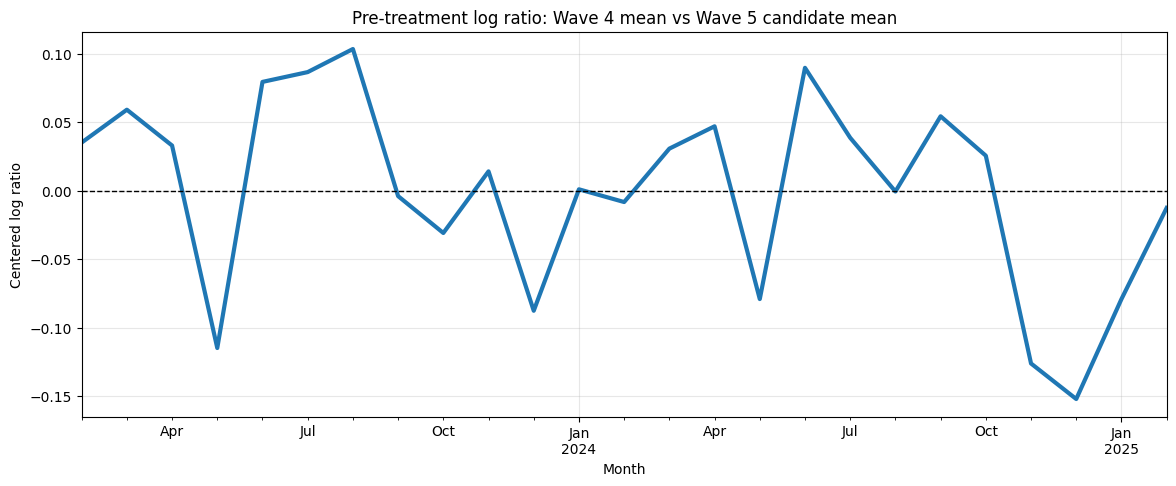

In [59]:
lp = np.log(monthly_wide_waves)

pre_end = pd.Timestamp("2025-02-28")

wave4_mean = lp[wave4].mean(axis=1)
wave5_mean = lp[wave5].mean(axis=1)

wave4_vs_wave5 = wave4_mean - wave5_mean

wave4_vs_wave5_centered = (
    wave4_vs_wave5 - wave4_vs_wave5.loc[:pre_end].mean()
)

plt.figure(figsize=(14, 5))

wave4_vs_wave5_centered.loc[:pre_end].plot(linewidth=3)

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title("Pre-treatment log ratio: Wave 4 mean vs Wave 5 candidate mean")
plt.ylabel("Centered log ratio")
plt.xlabel("Month")
plt.grid(alpha=0.3)
plt.show()

In [60]:
wave4_vs_wave5_pre = wave4_vs_wave5_centered.loc[:pre_end]

wave4_vs_wave5_pre.describe()

count    2.500000e+01
mean    -4.085621e-16
std      7.082533e-02
min     -1.521489e-01
25%     -3.096472e-02
50%      1.400134e-02
75%      4.690375e-02
max      1.033042e-01
dtype: float64

In [61]:
wave4_vs_wave5_pre.std(), wave4_vs_wave5_pre.min(), wave4_vs_wave5_pre.max()

(0.07082533312587598, -0.15214887289992118, 0.1033041997680848)

In [62]:
did_df = monthly_waves.copy()

did_df["log_pageviews"] = np.log(did_df["pageviews"])

wave4 = ["AT", "BE", "CH", "DE", "ES", "IE", "IT", "PL", "PT"]

wave5 = [
    "SK", "HU", "RO",
    "FI", "SE", "NO", "DK",
    "LT", "LV", "EE"
]

did_df = did_df[
    did_df["country_code"].isin(wave4 + wave5)
].copy()

did_df["treated"] = did_df["country_code"].isin(wave4).astype(int)

did_df["post"] = (did_df["month"] >= pd.Timestamp("2025-03-01")).astype(int)

did_df["did"] = did_df["treated"] * did_df["post"]

did_df.head()

,country_code,month,pageviews,log_pageviews,treated,post,did
0,AT,2023-02-01,9216110,16.036464,1,0,0
1,AT,2023-03-01,12132565,16.311404,1,0,0
2,AT,2023-04-01,10328430,16.150411,1,0,0
3,AT,2023-05-01,11114971,16.223803,1,0,0
4,AT,2023-06-01,9146060,16.028834,1,0,0


In [63]:
did_df.groupby(["treated", "post"])["country_code"].count()

treated  post
0        0       250
         1       160
1        0       225
         1       144
Name: country_code, dtype: int64

## Difference-in-Differences estimation

The pre-treatment diagnostics suggest that the aggregate Wave 5 countries provide a more appropriate comparison group than any single country.

The Difference-in-Differences model therefore compares Wave 4 countries (March 2025 rollout) against the delayed rollout countries while controlling for country and month fixed effects.

In [71]:
import statsmodels.formula.api as smf

In [72]:
model = smf.ols(
    "log_pageviews ~ did + C(country_code) + C(month)",
    data=did_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": did_df["country_code"]}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          log_pageviews   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     531.0
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           7.02e-21
Time:                        18:52:29   Log-Likelihood:                 451.41
No. Observations:                 779   AIC:                            -782.8
Df Residuals:                     719   BIC:                            -503.3
Df Model:                          59                                         
Covariance Type:              cluster                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

/srv/paws/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 59, but rank is 18
  warnings.warn('covariance of constraints does not have full '


The estimated treatment effect is summarized below.

The coefficient of the interaction term (`did`) represents the average change in log pageviews for Wave 4 countries after the AI Overviews rollout relative to the delayed-rollout comparison group.

In [73]:
results = pd.DataFrame({
    "coef": model.params,
    "pvalue": model.pvalues
})

results["ci_low"] = model.conf_int()[0]
results["ci_high"] = model.conf_int()[1]

results.loc[["did"]]

,coef,pvalue,ci_low,ci_high
did,-0.023312,0.706493,-0.144647,0.098022


In [74]:
short_df = did_df[
    did_df["month"] <= pd.Timestamp("2025-05-01")
].copy()

model_short = smf.ols(
    "log_pageviews ~ did + C(country_code) + C(month)",
    data=short_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": short_df["country_code"]}
)

short_results = pd.DataFrame({
    "coef": model_short.params,
    "pvalue": model_short.pvalues
})

short_results["ci_low"] = model_short.conf_int()[0]
short_results["ci_high"] = model_short.conf_int()[1]

short_results.loc[["did"]]

,coef,pvalue,ci_low,ci_high
did,-0.073529,0.272719,-0.204921,0.057863


The estimated treatment effect is negative but statistically insignificant.

The 95% confidence interval includes zero, indicating that the observed differences are compatible with random variation in country-level pageview dynamics.

At this level of aggregation, the analysis does not provide evidence that the March 2025 AI Overviews rollout produced a detectable change in Wikipedia pageviews.

## Sensitivity analysis

Because additional countries gradually received AI Overviews during the following months, a shorter post-treatment window is also estimated to reduce potential contamination of the comparison group.

In [75]:
coef = short_results.loc["did", "coef"]
ci_low = short_results.loc["did", "ci_low"]
ci_high = short_results.loc["did", "ci_high"]

pd.Series({
    "effect_pct": (np.exp(coef) - 1) * 100,
    "ci_low_pct": (np.exp(ci_low) - 1) * 100,
    "ci_high_pct": (np.exp(ci_high) - 1) * 100,
    "pvalue": short_results.loc["did", "pvalue"]
})

effect_pct     -7.089063
ci_low_pct    -18.528822
ci_high_pct     5.957008
pvalue          0.272719
dtype: float64

Restricting the analysis to the uncontaminated post-treatment period produces a similar result.

The estimated treatment effect remains negative (approximately −7%), but the confidence interval still includes zero.

This suggests that the conclusion is robust to the choice of the post-treatment window and that no detectable country-level effect can be identified using this design.


# Final conclusion

This notebook evaluated whether the March 2025 AI Overviews rollout reduced Wikipedia pageviews using a country-level Difference-in-Differences design.

Several alternative control strategies were explored. France was rejected as a single control because pre-treatment diagnostics revealed a France-specific shock. An aggregate delayed-rollout control based on Wave 5 countries produced substantially more stable pre-treatment behavior.

The final Difference-in-Differences model estimated a negative but statistically insignificant treatment effect. Restricting the analysis to the uncontaminated post-treatment period led to the same qualitative conclusion.

Overall, this study finds no detectable evidence of a country-level impact of AI Overviews on Wikipedia pageviews. These findings suggest that country-level aggregation may be too coarse to detect the expected impact, even when using an improved identification strategy.